# Simulation studies for 'Achieving and Assessing Calibration in Many Tests'
Adway Wadekar

In [392]:
import numpy as np
import pandas as pd
from npeb import Grenander, local_fdr
import scipy.stats as stats
from scipy.io import loadmat
import matplotlib.pyplot as plt
import seaborn as sns

## Helper functions

In [86]:
# function to make simulated p-values
def make_pvals(n, pi0, alpha = 0.5, beta = 1.0):
    n0 = int(pi0 * n)
    n1 = n - n0
    pvals = np.concatenate([np.random.uniform(size=n0), np.random.beta(a=alpha, b=beta, size=n1)])
    labels = np.concatenate([np.zeros(n0), np.ones(n1)])
    perm = np.random.permutation(n)
    pvals = pvals[perm]
    labels = labels[perm]
    return labels, pvals

# make q-values from p-values
def qvalues(pvals, lam=0.5):
    pvals = np.asarray(pvals)
    m = len(pvals)

    # sort p-values
    order = np.argsort(pvals)
    p_sorted = pvals[order]

    # estimate pi0
    pi0 = np.mean(pvals > lam) / (1 - lam)
    pi0 = min(pi0, 1.0)

    # compute initial q-values (i.e. pFDRs for each p-value)
    qvals = m * p_sorted * pi0 / np.arange(1, m + 1)

    # enforce monotonicity by taking minimum at each step
    qvals = np.minimum.accumulate(qvals[::-1])[::-1]
    qvals = np.minimum(qvals, 1.0)

    # return in original order
    # q_original = np.empty_like(qvals)
    # q_original[order] = qvals

    q_original = qvals[np.argsort(order)]

    return q_original

## Example experiment (lfdr calibration)

In [463]:
labels, pvals = make_pvals(n=1000000, pi0=0.95, alpha=0.5, beta=2.3)
qvals = qvalues(pvals, lam=0.5)

train_idx = np.random.choice(len(pvals), size=int(0.5 * len(pvals)), replace=False)
train_pvals = pvals[train_idx]
train_labels = labels[train_idx]
test_pvals = pvals[~np.isin(pvals, train_pvals)]
test_labels = labels[~np.isin(pvals, train_pvals)]

In [464]:
gren = Grenander(x_min=0, x_max=1.0)
fhat = gren.fit(train_pvals)
lam = 1 - len(test_pvals)**(-1/5)
pi_hat_0_gren = np.mean(test_pvals > lam) / (1 - lam)
gren.pdf(test_pvals)
test_lfdr = pi_hat_0_gren / gren.pdf(test_pvals)

/var/folders/2p/pvl5m11d621fk0xffszjtbw80000gn/T/ipykernel_24878/3169483279.py:6: RuntimeWarning: divide by zero encountered in divide
  test_lfdr = pi_hat_0_gren / gren.pdf(test_pvals)


In [465]:
pi_hat_0_gren, lam

(np.float64(0.949529953017609), 0.9275220336322305)

          lfdr_bin         p_min     p_max    p_mean  lfdr_mean   count  \
0  (-0.001, 0.111]  5.391514e-12  0.000029  0.000010   0.059903     239   
1   (0.111, 0.222]  2.911627e-05  0.000131  0.000074   0.180876     298   
2   (0.222, 0.333]  1.329292e-04  0.000372  0.000239   0.263714     403   
3   (0.333, 0.444]  3.722810e-04  0.001365  0.000822   0.408885    1227   
4   (0.444, 0.556]  1.366961e-03  0.002245  0.001783   0.514671     781   
5   (0.556, 0.667]  2.246291e-03  0.005155  0.003638   0.580770    2323   
6   (0.667, 0.778]  5.155871e-03  0.017999  0.011357   0.709591    8619   
7   (0.778, 0.889]  1.800430e-02  0.103330  0.059527   0.852007   47707   
8     (0.889, 1.0]  1.033349e-01  0.976905  0.533926   0.969381  427614   

   proportion_true_nulls  p_bin_length  true_nulls_hat  \
0               0.054393      0.000029       13.807593   
1               0.194631      0.000102       48.471468   
2               0.243176      0.000239      113.318435   
3               0

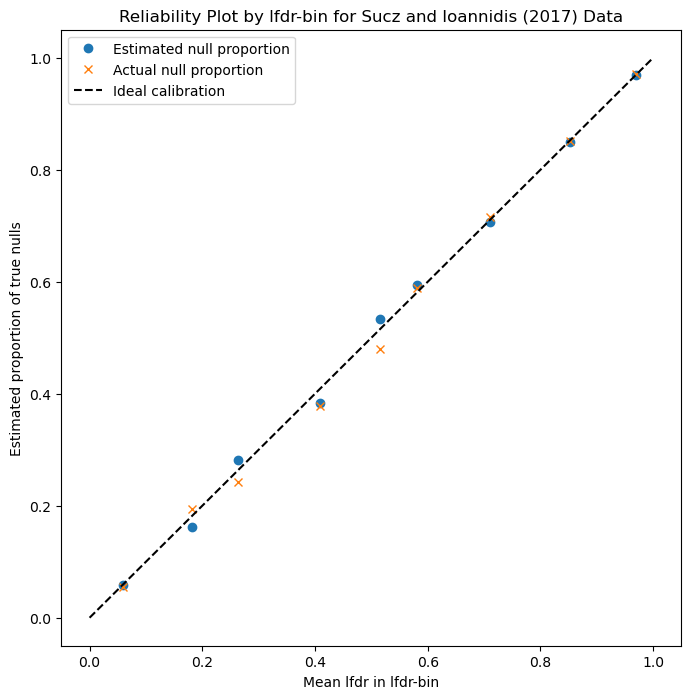

In [466]:
test_df = pd.DataFrame({
    'p_value': test_pvals,
    'lfdr': test_lfdr,
    'label': test_labels
})

# lfdr bins
bins = np.linspace(0, 1, 10)

# put lfdr  into bins
# df["lfdr_bin"] = pd.cut(df["lfdr"], bins=bins, include_lowest=True, right=True)
test_df["lfdr_bin"] = pd.cut(test_df["lfdr"], bins=bins, include_lowest=True, right=True)

# m = len(df)
m = len(test_df)

# summarize p-values within each lfdr-bin
lfdr_bin_stats = (
    test_df.groupby("lfdr_bin", observed=False)
      .agg(
          p_min=("p_value", "min"),
          p_max=("p_value", "max"),
          p_mean=("p_value", "mean"),
          lfdr_mean=("lfdr", "mean"),
          count=("p_value", "size"),
          proportion_true_nulls = ("label", "mean")
      )
      .reset_index()
)

lfdr_bin_stats["proportion_true_nulls"] = 1 - lfdr_bin_stats["proportion_true_nulls"]

# empirical p-range length induced by each lfdr-bin
lfdr_bin_stats["p_bin_length"] = lfdr_bin_stats["p_max"] - lfdr_bin_stats["p_min"]

# expected number of nulls in that p-interval under Storey's estimate
lfdr_bin_stats["true_nulls_hat"] = pi_hat_0_gren * m * lfdr_bin_stats["p_bin_length"]

# estimated null proportion within the lfdr-bin
lfdr_bin_stats["proportion_true_nulls_hat"] = np.minimum(
    lfdr_bin_stats["true_nulls_hat"] / lfdr_bin_stats["count"],
    1.0
)

lfdr_bin_stats["lfdr_bin_start"] = lfdr_bin_stats["lfdr_bin"].apply(lambda x: x.left)
lfdr_bin_stats["lfdr_bin_end"] = lfdr_bin_stats["lfdr_bin"].apply(lambda x: x.right)

print(lfdr_bin_stats)

# plot reliability plot for lfdr bins (estimated null proportion vs. mean lfdr in bin)

plt.figure(figsize=(8, 8))

plt.plot(lfdr_bin_stats["lfdr_mean"], lfdr_bin_stats["proportion_true_nulls_hat"], "o", label="Estimated null proportion")
plt.plot(lfdr_bin_stats["lfdr_mean"], lfdr_bin_stats["proportion_true_nulls"], "x", label="Actual null proportion")

plt.plot([0, 1], [0, 1], "k--", label="Ideal calibration")

plt.xlabel("Mean lfdr in lfdr-bin")
plt.ylabel("Estimated proportion of true nulls")
plt.title("Reliability Plot by lfdr-bin for Sucz and Ioannidis (2017) Data")

plt.legend()
plt.show()

### Expected calibration error

## Experiments